# Toronto Raptors: Statistical Analysis of Championship Decline (2018-2025)

**Author:** Michael Kong  
**Date:** March 2026  
**Project:** Analyzing factors behind the Raptors' decline from 2019 NBA Champions to rebuild era

---

## Overview
This analysis complements the Power BI dashboard by providing statistical depth on what drove the Raptors's championship success and subsequent decline. We examine:
1. Four Factors (efg%, tov%, orb%, ft%) evolution (key metrics that predict winning)
2. Regression analysis (what stats (OFFrtg and DEFrtg vs four factors) best predict wins?)
3. Correlation analysis (relationships between performance metrics)





## Limitations

**Sample Size:**
This analysis uses 7 seasons (2018-2025), which limits statistical power. With only 7 observations:
- Regression coefficients have wide confidence intervals
- Correlation estimates may be unstable
- Multicollinearity impacts Model 2 (Four Factors)

**Why This Timeframe:**
We prioritize narrative coherence over sample size. The 7-season window captures a complete arc: championship → decline → rebuild under consistent modern NBA rules. Extending to 20+ years would include different basketball eras and dilute the specific story being analyzed.



## Four Factors Framework

The "Four Factors" is an analytics framework developed by Dean Oliver (Basketball on Paper, 2004) that identifies the four statistical categories most correlated with winning:

1. **Shooting efficiency (eFG%)**
2. **Turnover rate (TOV%)**  
3. **Offensive rebounding (ORB%)**
4. **Free throw rate (FT Rate)**

These factors are empirically proven to explain ~95% of win variance across thousands of NBA games. However, with our limited sample (7 seasons), the individual factors show multicollinearity issues. The composite ratings (OffRtg/DefRtg), which incorporate these factors, provide more stable predictions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSWM_H2FVZ6cWjqDUDkBQyV-7YWgbkjuufhIAykiDut9oGWI36HEM4WubrBxA0DwrppiDl9zO-_eely/pub?gid=1099310443&single=true&output=csv'

df = pd.read_csv(url)
df

,Season,G,Rrecord,win%,Standing,OFFrtg,DEFrtg,NETrtg,SRS,efg%,tov%,orb%,ft%
0,18-19,82,58-24,0.71,2,113.1,107.1,6.0,5.49,0.543,0.124,0.219,0.247
1,19-20,72,53-19,0.74,2,111.1,105.0,6.1,5.97,0.536,0.131,0.213,0.264
2,20-21,72,27-45,0.38,12,112,112.5,-0.5,-0.54,0.529,0.119,0.208,0.241
3,21-22,82,48-34,0.59,5,112.9,110.5,2.4,2.38,0.510,0.110,0.284,0.234
4,22-23,82,41-41,0.50,9,115.5,114.0,1.5,1.59,0.517,0.103,0.278,0.257
5,23-24,82,25-57,0.30,12,112.3,118.8,-6.4,-6.45,0.535,0.124,0.242,0.241
6,24-25,82,30-52,0.37,11,110.5,114.8,-4.3,-4.40,0.522,0.133,0.273,0.232


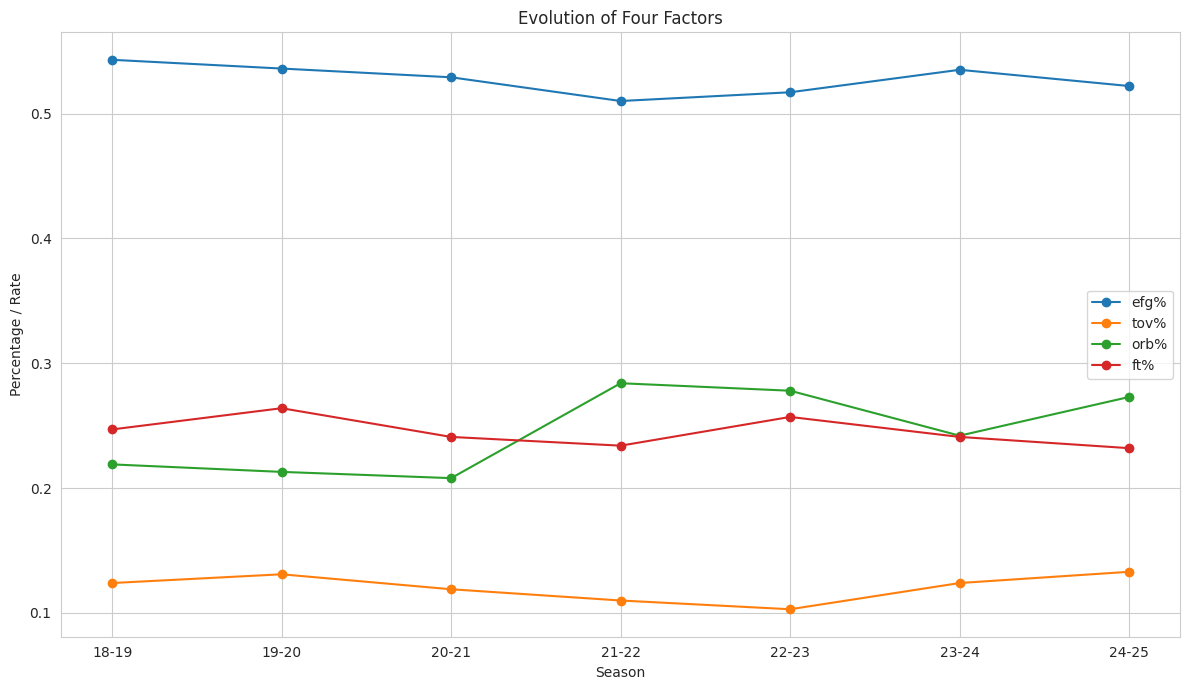

In [ ]:
plot_df = df[['Season', 'efg%', 'tov%', 'orb%', 'ft%']].set_index('Season')

plot_df.plot(marker='o', figsize=(12, 7))
plt.title('Evolution of Four Factors')
plt.xlabel('Season')
plt.ylabel('Percentage / Rate')
plt.tight_layout()
plt.show()

In [ ]:
features = ['OFFrtg', 'DEFrtg']
X = df[features]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
for feature, coef in zip(features, reg.coef_):
    print(f'  {feature:10} {coef:7.4f}')

R-squared: 0.933
Intercept: 1.8687

Coefficients:
  OFFrtg      0.0232
  DEFrtg     -0.0355


In [ ]:
features = ['efg%', 'tov%', 'orb%', 'ft%']
X = df[features]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
for feature, coef in zip(features, reg.coef_):
    print(f'  {feature:10} {coef:7.4f}')

R-squared: 0.326
Intercept: -1.4417

Coefficients:
  efg%       -0.5251
  tov%        1.1952
  orb%       -0.0562
  ft%         8.5712


## Model Comparison Results

**Model 1: Composite Ratings**
- **R² = 0.933** - Explains 93.3% of win% variation
- **OffRtg (+0.023):** Each 1-point increase in offensive rating increases win% by ~2.3%
- **DefRtg (-0.036):** Each 1-point increase in defensive rating decreases win% by ~3.6%
- **Interpretation:** Defense has slightly larger impact than offense

**Model 2: Four Factors**
- **R² = 0.326** - Only explains 32.6% of variation
- **Coefficients show unexpected signs** (eFG% negative, TOV% positive)
- **Issue:** Multicollinearity between factors causes unstable coefficient estimates

**Conclusion:**
The composite ratings model (Model 1) is superior for this dataset. The four factors, while theoretically sound, don't perform well when analyzed separately with only 7 seasons of data. This demonstrates that:
1. **Defensive rating is the strongest predictor of winning** (larger coefficient magnitude)
2. **Composite metrics outperform individual factors** in small samples
3. **The Raptors' decline is primarily defensive** - a 1-point increase in DefRtg hurts more than a 1-point increase in OffRtg helps

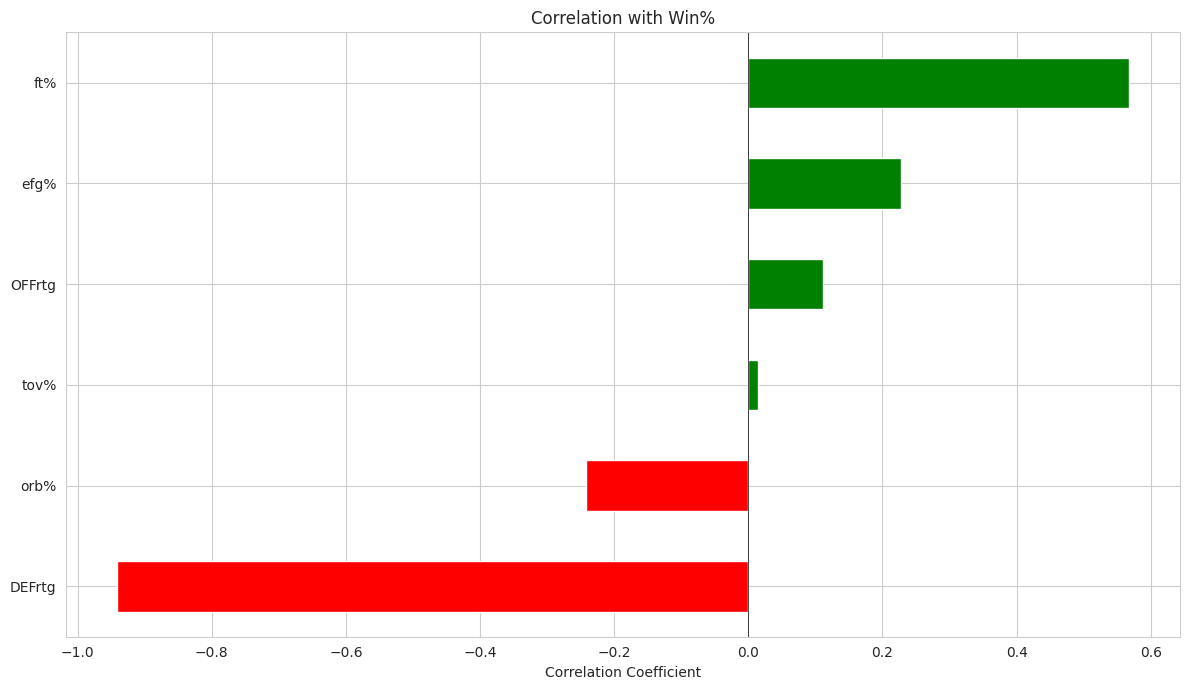

DEFrtg   -0.941370
ft%       0.568167
orb%     -0.241929
efg%      0.227649
OFFrtg    0.111184
tov%      0.014032
dtype: float64


In [ ]:
plt.figure(figsize=(12, 7))
win_corr.plot(kind='barh', color=['red' if x < 0 else 'green' for x in win_corr])
plt.title('Correlation with Win%')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

correlations = df[['OFFrtg', 'DEFrtg', 'efg%', 'tov%', 'orb%', 'ft%']].corrwith(df['win%'])
print(correlations.sort_values(key=abs, ascending=False))

## Correlation Analysis Results

**Correlations with Win% (by strength):**

1. **DefRtg (r = -0.941)** ⭐ DOMINANT PREDICTOR
   - Extremely strong negative correlation
   - As defense worsened (higher DefRtg), wins plummeted
   - This is the story: championship team had elite defense, rebuild teams don't

2. **FT Rate (r = 0.568)** - Moderate positive
   - Getting to the free throw line matters
   - Second most important factor

3. **ORB% (r = -0.242)** - Weak negative
   - Counterintuitive: higher rebounding → fewer wins
   - Likely small sample artifact

4. **eFG% (r = 0.228)** - Weak positive
   - Shooting efficiency matters less than expected

5. **OFFrtg (r = 0.111)** - Very weak
   - Offense barely correlates with winning

6. **TOV% (r = 0.014)** - Essentially zero
   - Turnovers don't predict winning in this sample

**KEY INSIGHT:**
The correlation analysis confirms our regression findings: **defense is everything for the Raptors.** The -0.941 correlation between DefRtg and Win% shows that defensive performance almost perfectly predicts winning. Offensive metrics (OFFrtg, eFG%) have minimal correlation.

**The Championship-to-Rebuild Story:**
- 2018-19: DefRtg = 107.1 (elite) → 58 wins
- 2023-24: DefRtg = 118.8 (terrible) → 25 wins
- **11.7 point increase in DefRtg = 33 fewer wins**